In [1]:
import numpy as np 
import cv2 
import matplotlib.pyplot as plt

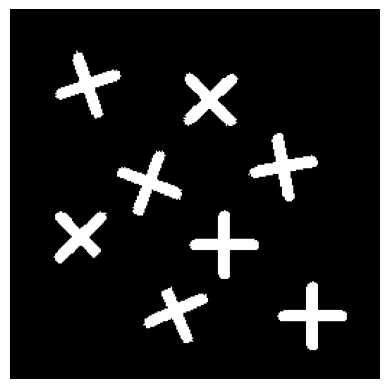

In [55]:
def load_image(url):
    img = cv2.imread(url,cv2.IMREAD_GRAYSCALE)
    return img
def display(img):
    plt.imshow(img,cmap='gray')
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()
image = load_image(r'/home/umerfarooq/DIP/DIP/stars.bmp')
display(image)

[]
[np.int64(1)]
[np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1)]
[np.int64(1)]
[np.int64(1)]
[np.int64(1)]
[np.int64(1)]
[np.int64(1)]
[np.int64(1)]
[np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1)]
[]
[np.int64(2)]
[np.int64(2)]
[np.int64(1), np.int64(2)]
[np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
[np.int64(1), np.int64(1), np

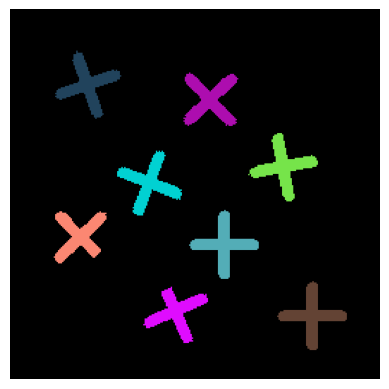

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def connected_component_labeling(binary_image):
    current_label = 1
    labels = np.zeros_like(binary_image, dtype=int)
    equivalence_table = {}
    for i in range(binary_image.shape[0]):
        for j in range(binary_image.shape[1]):
            if binary_image[i, j] in range(200,256):  # Only process object pixels
                # Get labels of the 8 neighbors
                neighbors = [
                    labels[i - 1, j - 1] if i > 0 and j > 0 else 0,  # top-left
                    labels[i - 1, j] if i > 0 else 0,                # top
                    labels[i - 1, j + 1] if i > 0 and j < binary_image.shape[1] - 1 else 0,  # top-right
                    labels[i, j - 1] if j > 0 else 0,                # left
                    labels[i, j + 1] if j < binary_image.shape[1] - 1 else 0,                # right
                    labels[i + 1, j - 1] if i < binary_image.shape[0] - 1 and j > 0 else 0,  # bottom-left
                    labels[i + 1, j] if i < binary_image.shape[0] - 1 else 0,                # bottom
                    labels[i + 1, j + 1] if i < binary_image.shape[0] - 1 and j < binary_image.shape[1] - 1 else 0  # bottom-right
                ]
                
                # Remove the background (zeros) from neighbors list
                neighbors = [label for label in neighbors if label != 0]
                print(neighbors)
                if len(neighbors) == 0:
                    # Case iv: No neighbors have a label
                    labels[i, j] = current_label
                    equivalence_table[current_label] = current_label
                    current_label += 1
                else:
                    # Case iii: Neighbors with labels
                    min_label = min(neighbors)
                    labels[i, j] = min_label
                    
                    # Record equivalences
                    for neighbor_label in neighbors:
                        if neighbor_label != min_label:
                            equivalence_table[max(min_label, neighbor_label)] = min(min_label, neighbor_label)

    # Second pass: Replace each label with the smallest equivalent label
    for i in range(binary_image.shape[0]):
        for j in range(binary_image.shape[1]):
            if labels[i, j] != 0:
                # Trace back to find the smallest equivalent label
                root_label = labels[i, j]
                while equivalence_table[root_label] != root_label:
                    root_label = equivalence_table[root_label]
                labels[i, j] = root_label

    return labels

def generate_colored_image(labeled_image):
    height, width = labeled_image.shape
    color_image = np.zeros((height, width, 3), dtype=np.uint8)

    # Generate a random color for each label
    unique_labels = np.unique(labeled_image)
    print("Unique labels:", unique_labels)  # Debugging: Check unique labels
    label_colors = {label: np.random.randint(0, 256, size=3) for label in unique_labels if label != 0}

    # If label_colors is empty, print a message
    if not label_colors:
        print("No non-zero labels found. Ensure binary image has object pixels (1s).")

    # Assign colors to each label in the color image
    for i in range(height):
        for j in range(width):
            label = labeled_image[i, j]
            if label != 0:
                print(i,j)
                color_image[i, j] = label_colors.get(label, [0, 0, 0])

    return color_image


# Example usage


labeled_image = connected_component_labeling(image)
colored_image = generate_colored_image(labeled_image)

print("Labeled Image:\n", labeled_image)
print("Colored Image:\n", colored_image)
plt.imshow(colored_image,)
plt.axis('off')  # Turn off axis numbers and ticks
plt.show()